# Sequence-level random forest for large-cluster membership

This notebook builds a sequence-level modelling table from `data/processed/scotland_clustering_analysis_dataset.parquet`, assigns each sequence at the primary Leiden resolution to `singleton`, `small_cluster`, or `large_cluster`, then fits random forest models to test whether demographic, deprivation, vaccination, and reinfection features are associated with membership in large detected genomic clusters after adjusting for local surveillance and incidence.

Primary design:

- Primary resolution: `resolution == 0.3`
- QC filter: `nextclade_qc in {good, mediocre}`
- Window de-duplication: one row per `sequence_id`, choosing the row closest to `wn_mid_date`
- Cluster categories: `singleton = 1`, `small_cluster = 2-12`, `large_cluster >= 13`
- Primary model: binary random forest, `large_cluster` versus all other sequences
- Secondary model: binary random forest, `singleton` versus `small_or_large_cluster`
- Tertiary model: three-class random forest, `singleton` versus `small_cluster` versus `large_cluster`
- Leakage control: grouped train/test split by `cluster_id`
- Main SIMD specification: one overall SIMD measure only; domain decomposition is fitted separately

Interpretation should be framed as association with detected large-cluster membership, not causal proof of superspreading.

## 1. Setup

Set `RUN_MODE = "quick"` for a fast smoke test. Set `RUN_MODE = "final"` for the full forest and more stable permutation importance.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore",
    message=r"`sklearn\.utils\.parallel\.delayed` should be used with `sklearn\.utils\.parallel\.Parallel`.*",
    category=UserWarning,
    module=r"sklearn\.utils\.parallel",
)

PROJECT_ROOT = Path('/Users/ydnkka/Desktop/PhD Project/projects/scotland')
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'scotland_clustering_analysis_dataset.parquet'
OUT_DIR = PROJECT_ROOT / 'cluster_size_rf' / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_RESOLUTION = 0.3
PRIMARY_LARGE_MIN = 13
SENSITIVITY_LARGE_MINS = [10, 20]
RANDOM_STATE = 42
RUN_MODE = 'final'  # choose: 'quick' or 'final'

CONFIG = {
    'quick': {
        'n_estimators': 250,
        'min_samples_leaf': 50,
        'max_train_rows': 120_000,
        'max_perm_rows': 30_000,
        'perm_repeats': 5,
        'fit_secondary_multiclass': True,
    },
    'final': {
        'n_estimators': 1000,
        'min_samples_leaf': 20,
        'max_train_rows': None,
        'max_perm_rows': 75_000,
        'perm_repeats': 20,
        'fit_secondary_multiclass': True,
    },
}[RUN_MODE]

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')

print(f'Run mode: {RUN_MODE}')
print(f'Data: {DATA_PATH}')
print(f'Outputs: {OUT_DIR}')

Run mode: final
Data: /Users/ydnkka/Desktop/PhD Project/projects/scotland/data/processed/scotland_clustering_analysis_dataset.parquet
Outputs: /Users/ydnkka/Desktop/PhD Project/projects/scotland/cluster_size_rf/outputs


## 2. Load Analysis Columns

The notebook reads only the variables needed for the RF analysis. Outcome-defining columns are used only to construct labels and grouping variables; they are removed from predictors before modelling.

In [2]:
ID_COLUMNS = [
    'sequence_id', 'patient_id', 'cluster_id',
    'window_idx', 'window_id', 'resolution',
]

DATE_COLUMNS = [
    'collection_date', 'wn_mid_date',
]

OUTCOME_COLUMNS = [
    'cluster_size',
]

QC_COLUMNS = [
    'nextclade_qc',
]

FOCAL_SOCIODEMOGRAPHIC_COLUMNS = [
    'age_midpoint',
    'is_female',
    # Overall SIMD measures. Use one in the main model.
    'dz_simd_rank',
    'dz_simd_quintile',
    'dz_simd_decile',
    # SIMD domain ranks. Use all seven only in the decomposition model.
    'dz_simd_income_rank',
    'dz_simd_employment_rank',
    'dz_simd_education_rank',
    'dz_simd_health_rank',
    'dz_simd_access_rank',
    'dz_simd_crime_rank',
    'dz_simd_housing_rank',
    'dz_urban_rural_class',
    'dz_population_density',
]

FOCAL_VACCINATION_COLUMNS = [
    'is_vaccinated',
    'vacc_dose_number',
    'days_since_vaccination',
    'vacc_booster',
    'vacc_product_name',
    'is_reinfection',
]

SURVEILLANCE_INCIDENCE_COLUMNS = [
    'dz_cum_prop_sequenced',
    'dz_cum_incidence_per_capita',
    'dz_7d_test_positivity',
    'wn_prop_sequenced',
    'wn_no_sequences',
]

CONTEXT_COLUMNS = [
    'who_voc',
    'dz_health_board',
    'test_reason',
    'test_type',
]

SENSITIVITY_CONTEXT_COLUMNS = [
    'hb_hospital_occupancy',
    'hb_reinfection_rate',
    'dz_cum_prop_vaccinated',
]

READ_COLUMNS = sorted(set(
    ID_COLUMNS
    + DATE_COLUMNS
    + OUTCOME_COLUMNS
    + QC_COLUMNS
    + FOCAL_SOCIODEMOGRAPHIC_COLUMNS
    + FOCAL_VACCINATION_COLUMNS
    + SURVEILLANCE_INCIDENCE_COLUMNS
    + CONTEXT_COLUMNS
    + SENSITIVITY_CONTEXT_COLUMNS
))

raw = pd.read_parquet(DATA_PATH, columns=READ_COLUMNS)
print(f'Raw rows (sequence x window x resolution): {len(raw):,}')
print(f'Raw columns read: {len(raw.columns)}')
raw.head(3)

Raw rows (sequence x window x resolution): 7,287,320
Raw columns read: 35


,age_midpoint,cluster_id,cluster_size,collection_date,days_since_vaccination,dz_7d_test_positivity,dz_cum_incidence_per_capita,dz_cum_prop_sequenced,dz_cum_prop_vaccinated,dz_health_board,dz_population_density,dz_simd_access_rank,dz_simd_housing_rank,dz_simd_quintile,dz_urban_rural_class,hb_hospital_occupancy,hb_reinfection_rate,is_female,is_reinfection,is_vaccinated,nextclade_qc,patient_id,resolution,sequence_id,test_reason,test_type,vacc_booster,vacc_dose_number,vacc_product_name,who_voc,window_id,window_idx,wn_mid_date,wn_no_sequences,wn_prop_sequenced
0,47.0,W001|B.1.1.369|R0.8|S1,1,2020-07-04,NaN,0.022727,0.00135,1.0,NaN,Dumfries and Galloway,2987.023981,6847,3029.0,2,Accessible Small Towns,NaN,0.0,1.0,0.0,0.0,good,P000001,0.8,Scotland/CVR3946/2020,NaN,PCR,NaN,0.0,NaN,NaN,W001,1,2020-07-14 12:00:00,63,0.184211
1,47.0,W001|B.1.1.369|R0.1|S1,1,2020-07-04,NaN,0.022727,0.00135,1.0,NaN,Dumfries and Galloway,2987.023981,6847,3029.0,2,Accessible Small Towns,NaN,0.0,1.0,0.0,0.0,good,P000001,0.1,Scotland/CVR3946/2020,NaN,PCR,NaN,0.0,NaN,NaN,W001,1,2020-07-14 12:00:00,63,0.184211
2,47.0,W001|B.1.1.369|R0.2|S1,1,2020-07-04,NaN,0.022727,0.00135,1.0,NaN,Dumfries and Galloway,2987.023981,6847,3029.0,2,Accessible Small Towns,NaN,0.0,1.0,0.0,0.0,good,P000001,0.2,Scotland/CVR3946/2020,NaN,PCR,NaN,0.0,NaN,NaN,W001,1,2020-07-14 12:00:00,63,0.184211


## 3. Primary Resolution Filter and Window De-duplication

Rows are filtered to the primary clustering resolution and acceptable Nextclade QC. Because the source table has overlapping windows, each sequence is retained once, using the window midpoint closest to the collection date.

In [3]:
def build_sequence_table(
    source: pd.DataFrame,
    resolution: float = PRIMARY_RESOLUTION,
    large_min: int = PRIMARY_LARGE_MIN,
) -> pd.DataFrame:
    df = source.loc[
        source['resolution'].eq(resolution)
        & source['nextclade_qc'].isin(['good', 'mediocre'])
    ].copy()

    for col in DATE_COLUMNS:
        df[col] = pd.to_datetime(df[col])

    df['dist_to_mid'] = (df['collection_date'] - df['wn_mid_date']).abs()
    df = (
        df.sort_values(['sequence_id', 'dist_to_mid', 'window_idx'], kind='mergesort')
          .drop_duplicates('sequence_id', keep='first')
          .reset_index(drop=True)
    )

    df['cluster_type'] = np.select(
        [df['cluster_size'].eq(1), df['cluster_size'].between(2, large_min - 1)],
        ['singleton', 'small_cluster'],
        default='large_cluster',
    )
    df['cluster_type'] = pd.Categorical(
        df['cluster_type'],
        categories=['singleton', 'small_cluster', 'large_cluster'],
        ordered=True,
    )
    df['is_large_cluster'] = df['cluster_type'].eq('large_cluster').astype('int8')
    df['is_singleton'] = df['cluster_type'].eq('singleton').astype('int8')
    df['large_min_threshold'] = large_min
    return df

seq = build_sequence_table(raw, PRIMARY_RESOLUTION, PRIMARY_LARGE_MIN)
print(f'Primary modelling rows: {len(seq):,}')
print(f'Unique patients: {seq["patient_id"].nunique():,}')
print(f'Unique clusters: {seq["cluster_id"].nunique():,}')
seq[['sequence_id', 'cluster_id', 'collection_date', 'cluster_size', 'cluster_type']].head()

Primary modelling rows: 303,239
Unique patients: 296,245
Unique clusters: 90,402


,sequence_id,cluster_id,collection_date,cluster_size,cluster_type
0,Scotland/ALDP-10311D3/2021,W027|B.1.1.7|R0.3|C101,2021-01-14,208,large_cluster
1,Scotland/ALDP-1144EE4/2021,W028|B.1.1.7|R0.3|C213,2021-01-22,235,large_cluster
2,Scotland/ALDP-119F266/2021,W029|B.1.1.7|R0.3|S275,2021-01-27,1,singleton
3,Scotland/ALDP-1495CBA/2021,W037|B.1.1.7|R0.3|C317,2021-03-24,21,large_cluster
4,Scotland/ALDP-152F416/2021,W041|B.1.1.7|R0.3|C141,2021-04-23,43,large_cluster


## 4. Outcome Diagnostics

These checks make sure the outcome is not dominated by one variant or calendar period. Large detected clusters are expected to be common at the sequence level because a large cluster contributes many sequence rows.

In [4]:
outcome_counts = (
    seq['cluster_type']
    .value_counts(sort=False)
    .rename_axis('cluster_type')
    .reset_index(name='n_sequences')
)
outcome_counts['prop_sequences'] = outcome_counts['n_sequences'] / outcome_counts['n_sequences'].sum()
display(outcome_counts)

seq['collection_quarter'] = seq['collection_date'].dt.to_period('Q').astype(str)
seq['who_voc_display'] = seq['who_voc'].fillna('Other/Non-VOC')

voc_counts = pd.crosstab(seq['who_voc_display'], seq['cluster_type'])
voc_counts['total'] = voc_counts.sum(axis=1)
voc_counts['large_pct'] = 100 * voc_counts['large_cluster'] / voc_counts['total']
display(voc_counts.sort_values('total', ascending=False).round(1))

quarter_counts = pd.crosstab(seq['collection_quarter'], seq['cluster_type'])
quarter_counts['total'] = quarter_counts.sum(axis=1)
quarter_counts['large_pct'] = 100 * quarter_counts['large_cluster'] / quarter_counts['total']
display(quarter_counts.tail(12).round(1))

,cluster_type,n_sequences,prop_sequences
0,singleton,35958,0.11858
1,small_cluster,106258,0.35041
2,large_cluster,161023,0.53101


cluster_type,singleton,small_cluster,large_cluster,total,large_pct
who_voc_display,,,,,
Omicron,20693,55786,82798,159277,52.0
Delta,12280,39503,53663,105446,50.9
Alpha,1558,7170,19242,27970,68.8
Other/Non-VOC,1273,3457,4992,9722,51.3
recombinant,123,265,327,715,45.7
Beta,15,27,0,42,0.0
Eta,8,28,0,36,0.0
Gamma,4,12,0,16,0.0
Kappa,4,7,1,12,8.3


cluster_type,singleton,small_cluster,large_cluster,total,large_pct
collection_quarter,,,,,
2020Q3,230,689,2324,3243,71.7
2020Q4,671,1869,2585,5125,50.4
2021Q1,1264,5352,11959,18575,64.4
2021Q2,1333,5030,21133,27496,76.9
2021Q3,5360,15545,21868,42773,51.1
2021Q4,6396,22203,28277,56876,49.7
2022Q1,8381,25595,53654,87630,61.2
2022Q2,6468,19650,15346,41464,37.0
2022Q3,3384,6033,2711,12128,22.4


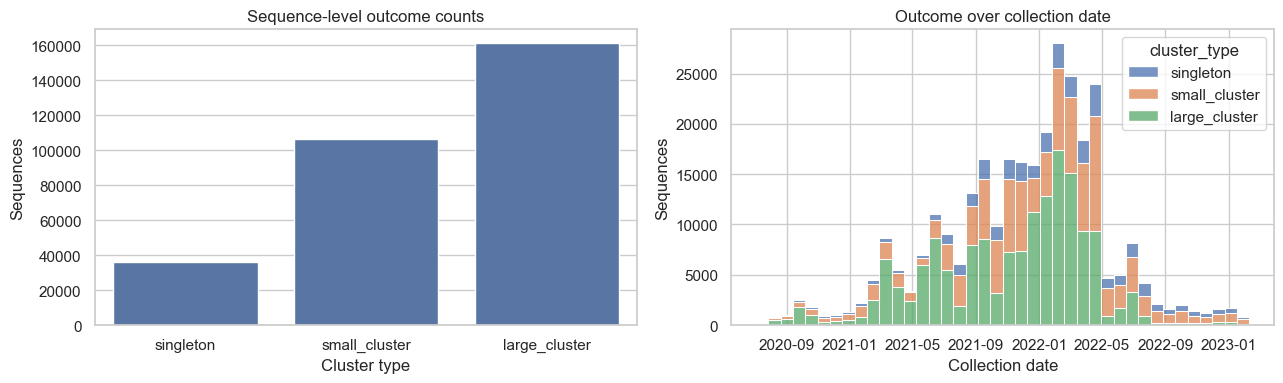

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=seq, x='cluster_type', order=['singleton', 'small_cluster', 'large_cluster'], ax=axes[0])
axes[0].set_title('Sequence-level outcome counts')
axes[0].set_xlabel('Cluster type')
axes[0].set_ylabel('Sequences')

plot_voc = seq.loc[seq['who_voc_display'].isin(seq['who_voc_display'].value_counts().head(5).index)].copy()
sns.histplot(
    data=plot_voc,
    x='collection_date',
    hue='cluster_type',
    multiple='stack',
    bins=40,
    ax=axes[1],
)
axes[1].set_title('Outcome over collection date')
axes[1].set_xlabel('Collection date')
axes[1].set_ylabel('Sequences')
plt.tight_layout()

## 5. Feature Engineering

Vaccination fields are structurally missing for unvaccinated patients. For random forests, the cleanest representation is an explicit unvaccinated indicator plus sentinel/none values:

- `days_since_vaccination_model = -1` for unvaccinated
- `vacc_booster_model = 0` for unvaccinated
- `vacc_product_name_model = "None"` for unvaccinated

Single-day DZ testing counts are deliberately excluded. The model instead uses cumulative sequencing fraction, cumulative incidence, 7-day positivity, and window-level sequencing intensity.

In [6]:
TEST_REASON_MAP = {
    # symptomatic_citizen
    'symptomatic-citizen': 'symptomatic_citizen',
    'I have coronavirus symptoms': 'symptomatic_citizen',
    'I live~ work or study in a lockdown area with a coronavirus outbreak': 'symptomatic_citizen',

    # symptomatic_essential_worker
    'symptomatic-essential-worker': 'symptomatic_essential_worker',
    'Im an essential worker': 'symptomatic_essential_worker',
    'scotland-wales-keyworker': 'symptomatic_essential_worker',
    'wales-keyworker': 'symptomatic_essential_worker',

    # contact_tracing
    'test-for-contact-tracing': 'contact_tracing',
    'test-for-contact-tracing-app': 'contact_tracing',
    'test-for-contact-self-referral': 'contact_tracing',
    'for-symptomatic-household-member': 'contact_tracing',
    'Ive been in contact with a person who has tested positive for coronavirus and Ive been asked to take a test by a contact tracer (Northern Ireland and Scotland)': 'contact_tracing',
    'Ive been in contact with a person who has tested positive for coronavirus and have since developed symptoms': 'contact_tracing',

    # confirmatory
    'confirmatory-positive-test': 'confirmatory',
    'confirmatory-other-reason': 'confirmatory',
    'confirmatory-test-unclear': 'confirmatory',
    'confirmatory-test-borders': 'confirmatory',
    'told-to-order-repeat-test': 'confirmatory',

    # isolation_scheme
    'self-isolation-support-grant': 'isolation_scheme',
    'isolation-testing-home': 'isolation_scheme',
    'isolation-testing-facility': 'isolation_scheme',

    # clinical
    'gp-healthcare-request': 'clinical',
    'antiviral-order': 'clinical',
    'dental-patient-testing': 'clinical',
    'I have been told to have a test before I go into hospital~ for example~ for surgery': 'clinical',

    # surveillance_research
    'zoe-symptom-study': 'surveillance_research',
    'contact-testing-study': 'surveillance_research',
    'events-research-programme': 'surveillance_research',
    'serial-testing': 'surveillance_research',
    'ntrg-member': 'surveillance_research',

    # local_outbreak
    'local-council-request': 'local_outbreak',
    'attended-outbreak-venue': 'local_outbreak',
    'community-testing': 'local_outbreak',
    'scotland-university': 'local_outbreak',
    'wales-university': 'local_outbreak',

    # travel
    'green-traveller': 'travel',

    # other
    'other': 'other',
    'Other': 'other',
    'none': 'other',
    'do-not-know': 'other',
    'general-cta-referral': 'other',
    'personal-assistant': 'other',
    'Im a visiting professional': 'other',
    'asymptomatic-home-order': 'other',
}

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out['days_since_epoch'] = (out['collection_date'] - pd.Timestamp('2020-01-01')).dt.days.astype('float64')
    out['log_dz_population_density'] = np.log1p(out['dz_population_density'].clip(lower=0))
    out['log_dz_cum_incidence_per_capita'] = np.log1p(out['dz_cum_incidence_per_capita'].clip(lower=0))
    out['log_wn_no_sequences'] = np.log1p(out['wn_no_sequences'].clip(lower=0))
    out['log_hb_hospital_occupancy'] = np.log1p(out['hb_hospital_occupancy'].clip(lower=0))

    out['is_unvaccinated'] = (out['is_vaccinated'].fillna(0).eq(0)).astype('int8')
    out['days_since_vaccination_model'] = out['days_since_vaccination'].where(out['is_unvaccinated'].eq(0), -1)
    out['vacc_booster_model'] = out['vacc_booster'].where(out['is_unvaccinated'].eq(0), 0)

    out['vacc_product_name_model'] = out['vacc_product_name'].astype('object')
    out.loc[out['is_unvaccinated'].eq(1), 'vacc_product_name_model'] = 'None'
    out['vacc_product_name_model'] = out['vacc_product_name_model'].fillna('Unknown')

    out['who_voc_model'] = out['who_voc'].fillna('Other/Non-VOC')
    out['test_reason_category'] = out['test_reason'].map(TEST_REASON_MAP)
    out['test_reason_unmapped'] = out['test_reason'].notna() & out['test_reason_category'].isna()
    out['test_reason_model'] = out['test_reason_category'].fillna('unknown')
    out['test_type_model'] = out['test_type'].fillna('Missing')
    out['dz_health_board_model'] = out['dz_health_board'].fillna('Missing')
    out['dz_urban_rural_class_model'] = out['dz_urban_rural_class'].fillna('Missing')

    return out

model_df = engineer_features(seq)

unmapped_test_reasons = sorted(
    model_df.loc[model_df['test_reason_unmapped'], 'test_reason']
    .dropna()
    .unique()
)
print(f'Unmapped non-missing test_reason values: {len(unmapped_test_reasons)}')
if unmapped_test_reasons:
    display(pd.Series(unmapped_test_reasons, name='unmapped_test_reason').to_frame())
display(
    model_df['test_reason_model']
    .value_counts(dropna=False)
    .rename_axis('test_reason_model')
    .to_frame('n_sequences')
)

# Main analysis uses exactly one overall SIMD measure to avoid collinearity.
# Options: 'quintile' (default, interpretable), 'decile' (finer ordinal), or 'rank' (continuous full rank).
SIMD_OVERALL_MODE = 'quintile'
SIMD_OVERALL_FEATURE_BY_MODE = {
    'rank': 'dz_simd_rank',
    'quintile': 'dz_simd_quintile',
    'decile': 'dz_simd_decile',
}
SIMD_OVERALL_FEATURE = SIMD_OVERALL_FEATURE_BY_MODE[SIMD_OVERALL_MODE]

SIMD_DOMAIN_FEATURES = [
    'dz_simd_income_rank',
    'dz_simd_employment_rank',
    'dz_simd_education_rank',
    'dz_simd_health_rank',
    'dz_simd_access_rank',
    'dz_simd_crime_rank',
    'dz_simd_housing_rank',
]

PRIMARY_NUMERIC_FEATURES = [
    # focal sociodemographic: one overall SIMD measure only
    'age_midpoint',
    'is_female',
    SIMD_OVERALL_FEATURE,
    'log_dz_population_density',
    # focal vaccination and reinfection
    'vacc_dose_number',
    'is_unvaccinated',
    'days_since_vaccination_model',
    'vacc_booster_model',
    'is_reinfection',
    # surveillance and incidence adjustment
    'dz_cum_prop_sequenced',
    'log_dz_cum_incidence_per_capita',
    'dz_7d_test_positivity',
    'wn_prop_sequenced',
    'log_wn_no_sequences',
    # calendar adjustment
    'days_since_epoch',
]

PRIMARY_CATEGORICAL_FEATURES = [
    'who_voc_model',
    'dz_health_board_model',
    'dz_urban_rural_class_model',
    'test_reason_model',
    'test_type_model',
    'vacc_product_name_model',
]

SENSITIVITY_NUMERIC_FEATURES = [
    'log_hb_hospital_occupancy',
    'hb_reinfection_rate',
    'dz_cum_prop_vaccinated',
]

USE_SENSITIVITY_CONTEXT_CONTROLS = False

NUMERIC_FEATURES = PRIMARY_NUMERIC_FEATURES + (SENSITIVITY_NUMERIC_FEATURES if USE_SENSITIVITY_CONTEXT_CONTROLS else [])
CATEGORICAL_FEATURES = PRIMARY_CATEGORICAL_FEATURES
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

# Domain decomposition replaces the overall SIMD measure with all seven SIMD domain ranks.
DECOMPOSITION_NUMERIC_FEATURES = [
    f for f in NUMERIC_FEATURES if f != SIMD_OVERALL_FEATURE
] + SIMD_DOMAIN_FEATURES
DECOMPOSITION_FEATURES = DECOMPOSITION_NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = model_df[ALL_FEATURES].copy()
y_binary = model_df['is_large_cluster'].copy()
y_singleton = model_df['is_singleton'].copy()
y_multiclass = model_df['cluster_type'].astype(str).copy()
groups = model_df['cluster_id'].copy()

missing_summary = X.isna().mean().mul(100).sort_values(ascending=False).rename('missing_pct').to_frame()
display(missing_summary)
print(f'Main SIMD overall mode: {SIMD_OVERALL_MODE} -> {SIMD_OVERALL_FEATURE}')
print(f'Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} pre-encoded features')
print(f'Domain-decomposition feature matrix would use {len(DECOMPOSITION_FEATURES)} pre-encoded features')


,missing_pct
dz_7d_test_positivity,0.011872
dz_cum_prop_sequenced,0.003628
log_dz_cum_incidence_per_capita,0.000000
test_type_model,0.000000
test_reason_model,0.000000
dz_urban_rural_class_model,0.000000
dz_health_board_model,0.000000
who_voc_model,0.000000
days_since_epoch,0.000000
log_wn_no_sequences,0.000000


Feature matrix: 303,239 rows x 23 pre-encoded features


## 6. Preprocessor and Random Forest

Numeric variables get median imputation with missingness indicators. Categorical variables get a constant missing level and one-hot encoding. This keeps the model robust if sensitivity controls introduce missingness.

In [7]:
def make_one_hot_encoder() -> OneHotEncoder:
    # scikit-learn 1.2+ uses sparse_output; older versions use sparse.
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=20)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True, min_frequency=20)


def make_rf_pipeline(
    n_estimators: int = CONFIG['n_estimators'],
    min_samples_leaf: int = CONFIG['min_samples_leaf'],
    numeric_features: list[str] | None = None,
    categorical_features: list[str] | None = None,
) -> Pipeline:
    numeric_features = NUMERIC_FEATURES if numeric_features is None else numeric_features
    categorical_features = CATEGORICAL_FEATURES if categorical_features is None else categorical_features
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('onehot', make_one_hot_encoder()),
    ])
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipe, numeric_features),
            ('cat', categorical_pipe, categorical_features),
        ],
        remainder='drop',
        sparse_threshold=0.3,
        verbose_feature_names_out=False,
    )
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_features='sqrt',
        min_samples_leaf=min_samples_leaf,
        class_weight='balanced_subsample',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        oob_score=False,
    )
    return Pipeline([
        ('preprocessor', preprocessor),
        ('rf', rf),
    ])

binary_model = make_rf_pipeline()
binary_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

## 7. Grouped Train/Test Split

The holdout split is grouped by `cluster_id`, so a cluster cannot appear in both train and test. This is essential because all sequences in a cluster share the same outcome by construction.

In [8]:
def grouped_holdout_split(X, y, groups, test_size_approx: float = 0.2):
    n_splits = round(1 / test_size_approx)
    try:
        splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
        train_idx, test_idx = next(splitter.split(X, y, groups))
        split_name = f'StratifiedGroupKFold(n_splits={n_splits})'
    except Exception as exc:
        print(f'Falling back to GroupShuffleSplit because StratifiedGroupKFold failed: {exc}')
        splitter = GroupShuffleSplit(n_splits=1, test_size=test_size_approx, random_state=RANDOM_STATE)
        train_idx, test_idx = next(splitter.split(X, y, groups))
        split_name = 'GroupShuffleSplit'
    return train_idx, test_idx, split_name

train_idx, test_idx, split_name = grouped_holdout_split(X, y_binary, groups)
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y_binary.iloc[train_idx].copy()
y_test = y_binary.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

# Optional speed valve for notebook iteration. Grouping is preserved by sampling training clusters.
max_train_rows = CONFIG['max_train_rows']
if max_train_rows is not None and len(X_train) > max_train_rows:
    rng = np.random.default_rng(RANDOM_STATE)
    train_clusters = pd.Series(groups_train.unique())
    sampled_clusters = []
    n_rows = 0
    for cluster_id in rng.permutation(train_clusters.to_numpy()):
        mask_count = int((groups_train == cluster_id).sum())
        sampled_clusters.append(cluster_id)
        n_rows += mask_count
        if n_rows >= max_train_rows:
            break
    keep = groups_train.isin(sampled_clusters).to_numpy()
    X_train = X_train.loc[keep].copy()
    y_train = y_train.loc[keep].copy()
    groups_train = groups_train.loc[keep].copy()

print(f'Splitter: {split_name}')
print(f'Train rows: {len(X_train):,}; train clusters: {groups_train.nunique():,}')
print(f'Test rows : {len(X_test):,}; test clusters : {groups_test.nunique():,}')
print('\nBinary outcome balance:')
display(pd.concat([
    y_train.value_counts(normalize=True).rename('train'),
    y_test.value_counts(normalize=True).rename('test'),
], axis=1).rename(index={0: 'not_large', 1: 'large'}).round(3))

assert set(groups_train).isdisjoint(set(groups_test)), 'Cluster leakage: at least one cluster appears in train and test.'

Splitter: StratifiedGroupKFold(n_splits=5)
Train rows: 242,591; train clusters: 72,322
Test rows : 60,648; test clusters : 18,080

Binary outcome balance:


,train,test
is_large_cluster,,
large,0.531,0.531
not_large,0.469,0.469


## 8. Fit Primary Binary Random Forest

The primary target is membership in a detected large cluster (`cluster_size >= 13`) versus singleton/small-cluster membership.

In [9]:
binary_model.fit(X_train, y_train)
print('Finished fitting binary random forest')
print(binary_model.named_steps['rf'])

Finished fitting binary random forest
RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=20,
                       n_estimators=1000, n_jobs=-1, random_state=42)


## 9. Binary Model Evaluation

The large-cluster class is the class of scientific interest. Balanced accuracy, macro-F1, ROC-AUC, and average precision are more informative than raw accuracy.

In [10]:
def evaluate_binary_model(
    model: Pipeline,
    X_eval: pd.DataFrame,
    y_eval: pd.Series,
    label: str = 'holdout',
    negative_name: str = 'not_large',
    positive_name: str = 'large',
):
    pred = model.predict(X_eval)
    proba = model.predict_proba(X_eval)[:, 1]

    metrics = {
        'label': label,
        'n_rows': len(y_eval),
        'balanced_accuracy': balanced_accuracy_score(y_eval, pred),
        'macro_f1': f1_score(y_eval, pred, average='macro'),
        'roc_auc': roc_auc_score(y_eval, proba),
        'average_precision': average_precision_score(y_eval, proba),
    }
    cm = pd.DataFrame(
        confusion_matrix(y_eval, pred, labels=[0, 1]),
        index=[f'true_{negative_name}', f'true_{positive_name}'],
        columns=[f'pred_{negative_name}', f'pred_{positive_name}'],
    )
    report = classification_report(
        y_eval,
        pred,
        target_names=[negative_name, positive_name],
        digits=3,
        output_dict=True,
    )
    return metrics, cm, pd.DataFrame(report).T, proba, pred

binary_metrics, binary_cm, binary_report, binary_proba, binary_pred = evaluate_binary_model(binary_model, X_test, y_test)
display(pd.DataFrame([binary_metrics]).round(3))
display(binary_cm)
display(binary_report.round(3))

,label,n_rows,balanced_accuracy,macro_f1,roc_auc,average_precision
0,holdout,60648,0.663,0.663,0.712,0.708


,pred_not_large,pred_large
true_not_large,18468,9975
true_large,10430,21775


,precision,recall,f1-score,support
not_large,0.639,0.649,0.644,28443.000
large,0.686,0.676,0.681,32205.000
accuracy,0.664,0.664,0.664,0.664
macro avg,0.662,0.663,0.663,60648.000
weighted avg,0.664,0.664,0.664,60648.000


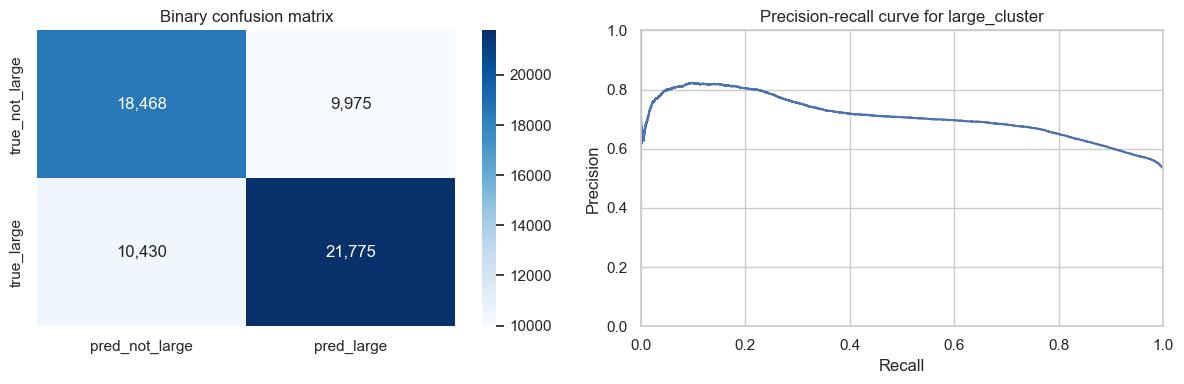

In [11]:
precision, recall, thresholds = precision_recall_curve(y_test, binary_proba)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(binary_cm, annot=True, fmt=',d', cmap='Blues', ax=axes[0])
axes[0].set_title('Binary confusion matrix')

axes[1].plot(recall, precision)
axes[1].set_title('Precision-recall curve for large_cluster')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
plt.tight_layout()

## 10. Permutation Importance

Permutation importance is computed on held-out rows, using average precision by default for the binary large-cluster model. It answers: how much does predictive performance fall when this feature is shuffled?

In [12]:
def sample_for_importance(X_eval, y_eval, max_rows: int, random_state: int = RANDOM_STATE):
    if max_rows is None or len(X_eval) <= max_rows:
        return X_eval, y_eval
    rng = np.random.default_rng(random_state)
    idx = rng.choice(len(X_eval), size=max_rows, replace=False)
    return X_eval.iloc[idx].copy(), y_eval.iloc[idx].copy()

X_perm, y_perm = sample_for_importance(X_test, y_test, CONFIG['max_perm_rows'])
print(f'Permutation rows: {len(X_perm):,}')

# n_jobs=1 avoids noisy sklearn/joblib worker warnings on Python 3.13.
# The forest itself is still trained with n_jobs=-1.
binary_perm = permutation_importance(
    binary_model,
    X_perm,
    y_perm,
    scoring='average_precision',
    n_repeats=CONFIG['perm_repeats'],
    random_state=RANDOM_STATE,
    n_jobs=1,
)

binary_importance = (
    pd.DataFrame({
        'feature': ALL_FEATURES,
        'mean_drop_average_precision': binary_perm.importances_mean,
        'std_drop_average_precision': binary_perm.importances_std,
    })
    .sort_values('mean_drop_average_precision', ascending=False)
    .reset_index(drop=True)
)
display(binary_importance)

Permutation rows: 60,648


,feature,mean_drop_average_precision,std_drop_average_precision
0,who_voc_model,0.115740,0.001404
1,days_since_epoch,0.042586,0.001765
2,log_wn_no_sequences,0.013497,0.000936
3,log_dz_cum_incidence_per_capita,0.004303,0.000581
4,wn_prop_sequenced,0.003469,0.001042
5,test_reason_model,0.002861,0.000317
6,dz_7d_test_positivity,0.001722,0.000301
7,dz_cum_prop_sequenced,0.001500,0.000135
8,dz_urban_rural_class_model,0.000868,0.000185
9,age_midpoint,0.000731,0.000237


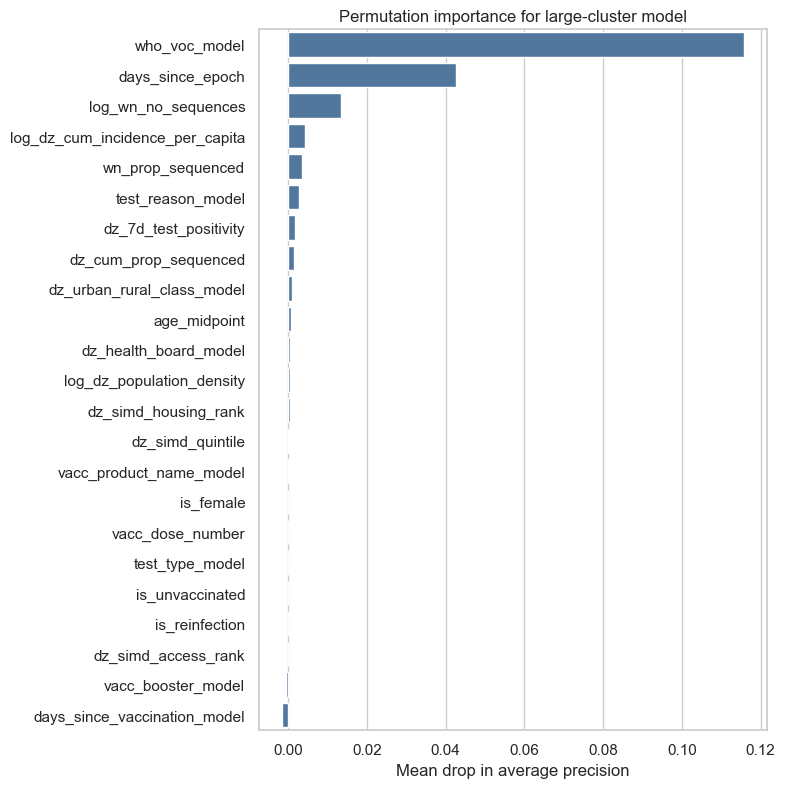

In [13]:
fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(binary_importance))))
sns.barplot(
    data=binary_importance.head(25),
    y='feature',
    x='mean_drop_average_precision',
    ax=ax,
    color='#4477AA',
)
ax.set_title('Permutation importance for large-cluster model')
ax.set_xlabel('Mean drop in average precision')
ax.set_ylabel('')
plt.tight_layout()

## 11. Secondary Binary Model: Singleton Versus Clustered

This model asks a different question from the large-cluster model: which variables distinguish sequences that remain singletons from sequences assigned to any multi-sequence cluster (`small_cluster` or `large_cluster`)?

Use this as a complementary ascertainment/transmission-structure analysis. It is especially useful for checking whether predictors are related to clustering at all, rather than specifically to large-cluster membership.


In [14]:
singleton_model = make_rf_pipeline()

y_singleton_train = y_singleton.loc[X_train.index].copy()
y_singleton_test = y_singleton.loc[X_test.index].copy()

singleton_model.fit(X_train, y_singleton_train)
print('Finished fitting singleton-versus-clustered random forest')

singleton_metrics, singleton_cm, singleton_report, singleton_proba, singleton_pred = evaluate_binary_model(
    singleton_model,
    X_test,
    y_singleton_test,
    label='holdout',
    negative_name='clustered',
    positive_name='singleton',
)

display(pd.DataFrame([singleton_metrics]).round(3))
display(singleton_cm)
display(singleton_report.round(3))

Finished fitting singleton-versus-clustered random forest


,label,n_rows,balanced_accuracy,macro_f1,roc_auc,average_precision
0,holdout,60648,0.604,0.583,0.663,0.226


,pred_clustered,pred_singleton
true_clustered,45377,8147
true_singleton,4551,2573


,precision,recall,f1-score,support
clustered,0.909,0.848,0.877,53524.000
singleton,0.240,0.361,0.288,7124.000
accuracy,0.791,0.791,0.791,0.791
macro avg,0.574,0.604,0.583,60648.000
weighted avg,0.830,0.791,0.808,60648.000


Singleton permutation rows: 60,648


,feature,mean_drop_average_precision,std_drop_average_precision
0,days_since_epoch,0.038221,0.002159
1,who_voc_model,0.029131,0.001007
2,log_wn_no_sequences,0.014790,0.001428
3,test_reason_model,0.007609,0.001013
4,age_midpoint,0.005938,0.000706
5,wn_prop_sequenced,0.005135,0.001023
6,log_dz_cum_incidence_per_capita,0.004620,0.001227
7,dz_7d_test_positivity,0.004001,0.000562
8,dz_cum_prop_sequenced,0.002319,0.000813
9,days_since_vaccination_model,0.001703,0.000533


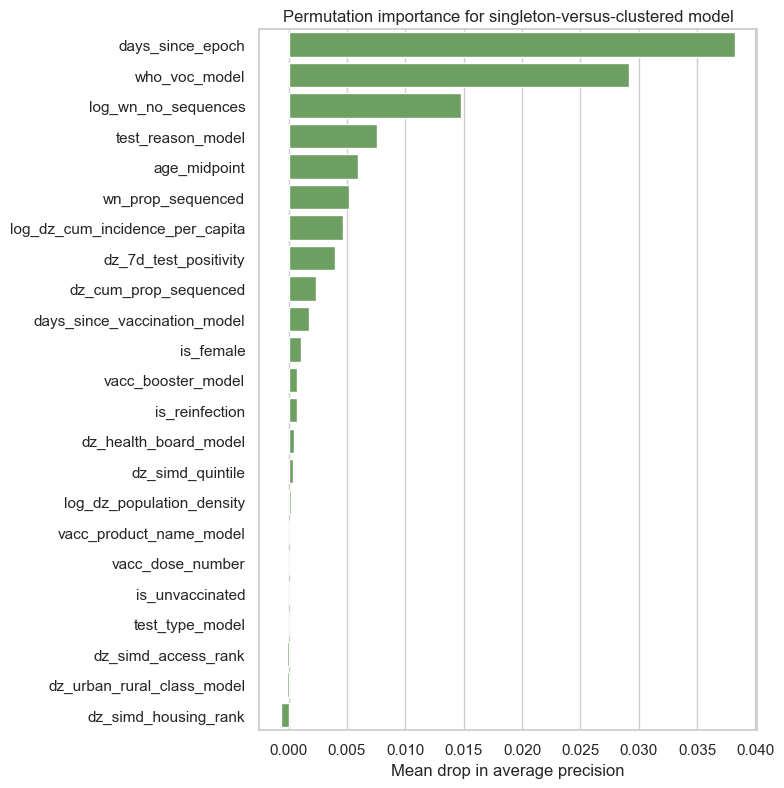

In [15]:
X_singleton_perm, y_singleton_perm = sample_for_importance(X_test, y_singleton_test, CONFIG['max_perm_rows'])
print(f'Singleton permutation rows: {len(X_singleton_perm):,}')

# n_jobs=1 avoids noisy sklearn/joblib worker warnings on Python 3.13.
singleton_perm = permutation_importance(
    singleton_model,
    X_singleton_perm,
    y_singleton_perm,
    scoring='average_precision',
    n_repeats=CONFIG['perm_repeats'],
    random_state=RANDOM_STATE,
    n_jobs=1,
)

singleton_importance = (
    pd.DataFrame({
        'feature': ALL_FEATURES,
        'mean_drop_average_precision': singleton_perm.importances_mean,
        'std_drop_average_precision': singleton_perm.importances_std,
    })
    .sort_values('mean_drop_average_precision', ascending=False)
    .reset_index(drop=True)
)
display(singleton_importance)

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(singleton_importance))))
sns.barplot(
    data=singleton_importance.head(25),
    y='feature',
    x='mean_drop_average_precision',
    ax=ax,
    color='#66AA55',
)
ax.set_title('Permutation importance for singleton-versus-clustered model')
ax.set_xlabel('Mean drop in average precision')
ax.set_ylabel('')
plt.tight_layout()

## 12. SIMD Domain Decomposition

The main model uses one overall SIMD measure. This decomposition model replaces that overall measure with all seven SIMD domain ranks: income, employment, education, health, geographic access, crime, and housing. Keep this as a secondary analysis because the domain ranks are correlated and importance can be shared across them.


In [ ]:
RUN_SIMD_DOMAIN_DECOMPOSITION = True

if RUN_SIMD_DOMAIN_DECOMPOSITION:
    X_decomp = model_df[DECOMPOSITION_FEATURES].copy()
    X_decomp_train = X_decomp.loc[X_train.index].copy()
    X_decomp_test = X_decomp.loc[X_test.index].copy()

    simd_domain_model = make_rf_pipeline(
        numeric_features=DECOMPOSITION_NUMERIC_FEATURES,
        categorical_features=CATEGORICAL_FEATURES,
    )
    simd_domain_model.fit(X_decomp_train, y_train)
    print('Finished fitting SIMD-domain decomposition random forest')

    simd_domain_metrics, simd_domain_cm, simd_domain_report, simd_domain_proba, simd_domain_pred = evaluate_binary_model(
        simd_domain_model,
        X_decomp_test,
        y_test,
        label='holdout_simd_domains',
        negative_name='not_large',
        positive_name='large',
    )

    display(pd.DataFrame([simd_domain_metrics]).round(3))
    display(simd_domain_cm)
    display(simd_domain_report.round(3))
else:
    simd_domain_model = None
    simd_domain_metrics = None
    simd_domain_cm = None
    simd_domain_report = None
    simd_domain_importance = None
    print('SIMD domain decomposition skipped.')


In [ ]:
if RUN_SIMD_DOMAIN_DECOMPOSITION:
    X_decomp_perm, y_decomp_perm = sample_for_importance(X_decomp_test, y_test, CONFIG['max_perm_rows'])
    print(f'SIMD decomposition permutation rows: {len(X_decomp_perm):,}')

    simd_domain_perm = permutation_importance(
        simd_domain_model,
        X_decomp_perm,
        y_decomp_perm,
        scoring='average_precision',
        n_repeats=CONFIG['perm_repeats'],
        random_state=RANDOM_STATE,
        n_jobs=1,
    )

    simd_domain_importance = (
        pd.DataFrame({
            'feature': DECOMPOSITION_FEATURES,
            'mean_drop_average_precision': simd_domain_perm.importances_mean,
            'std_drop_average_precision': simd_domain_perm.importances_std,
        })
        .sort_values('mean_drop_average_precision', ascending=False)
        .reset_index(drop=True)
    )
    display(simd_domain_importance)

    fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(simd_domain_importance))))
    sns.barplot(
        data=simd_domain_importance.head(30),
        y='feature',
        x='mean_drop_average_precision',
        ax=ax,
        color='#AA7744',
    )
    ax.set_title('Permutation importance for SIMD-domain decomposition model')
    ax.set_xlabel('Mean drop in average precision')
    ax.set_ylabel('')
    plt.tight_layout()


## 13. Direction-of-effect Checks

Random forests do not produce coefficients. Use partial dependence and, optionally, SHAP to inspect whether higher/lower values push predictions toward large-cluster membership. Partial dependence is usually enough for the core focal variables.

PDP rows: 20,000


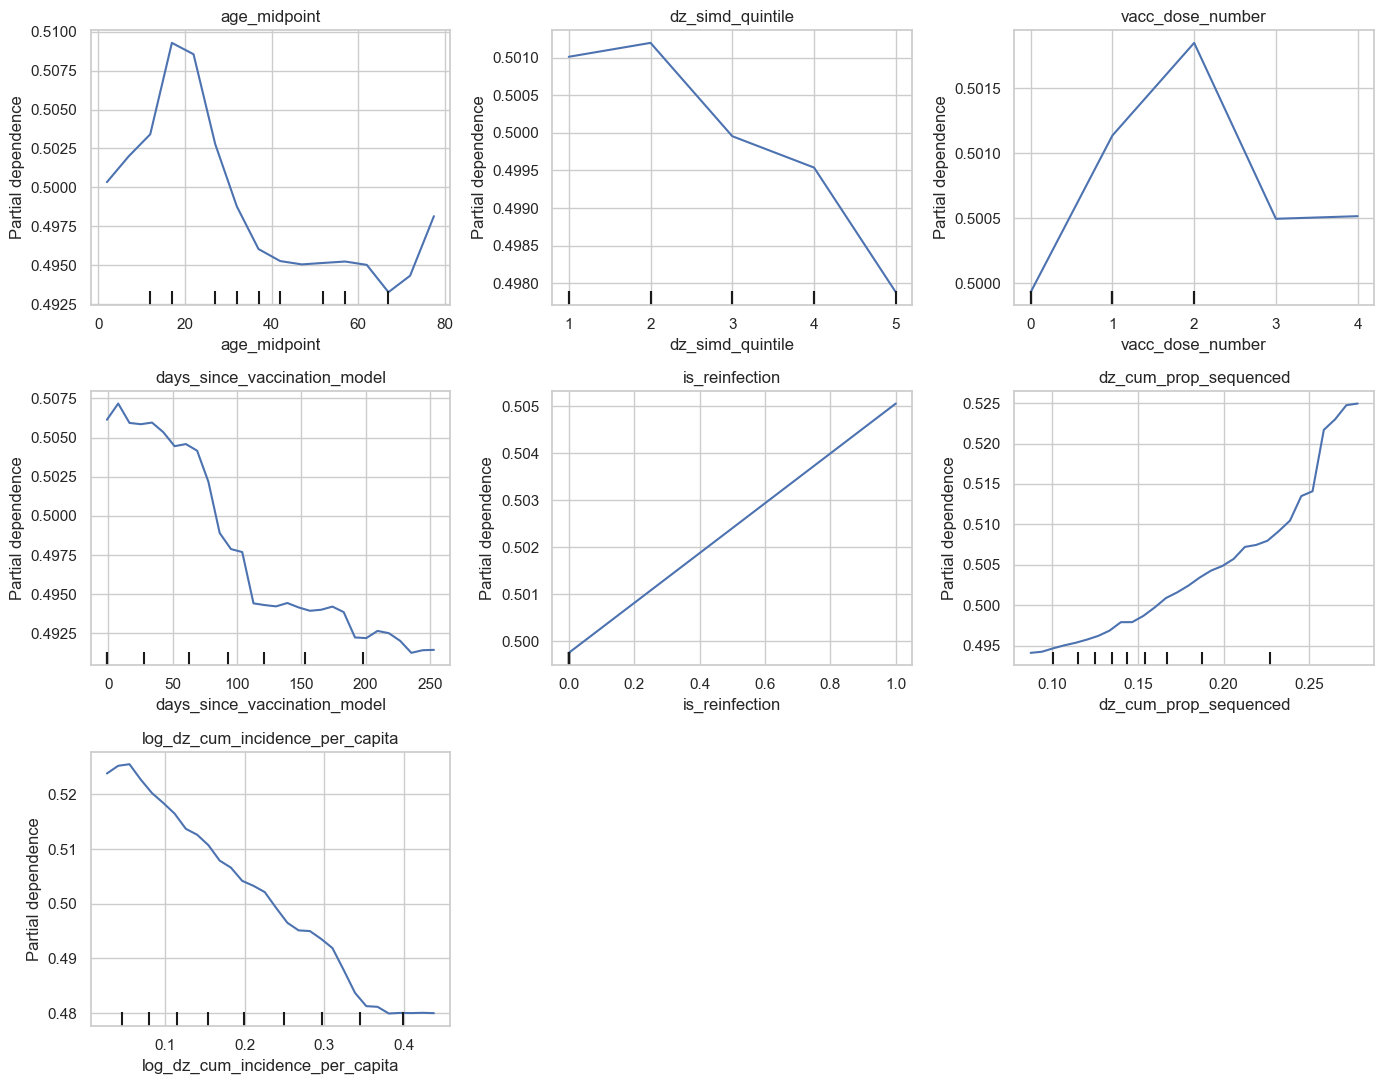

In [16]:
PDP_FEATURES = [
    'age_midpoint',
    SIMD_OVERALL_FEATURE,
    'vacc_dose_number',
    'days_since_vaccination_model',
    'is_reinfection',
    'dz_cum_prop_sequenced',
    'log_dz_cum_incidence_per_capita',
]

X_pdp, _ = sample_for_importance(X_test, y_test, max_rows=20_000)
print(f'PDP rows: {len(X_pdp):,}')

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for ax, feature in zip(axes, PDP_FEATURES):
    PartialDependenceDisplay.from_estimator(
        binary_model,
        X_pdp,
        [feature],
        target=1,
        kind='average',
        grid_resolution=30,
        ax=ax,
    )
    ax.set_title(feature)
for ax in axes[len(PDP_FEATURES):]:
    ax.axis('off')
plt.tight_layout()

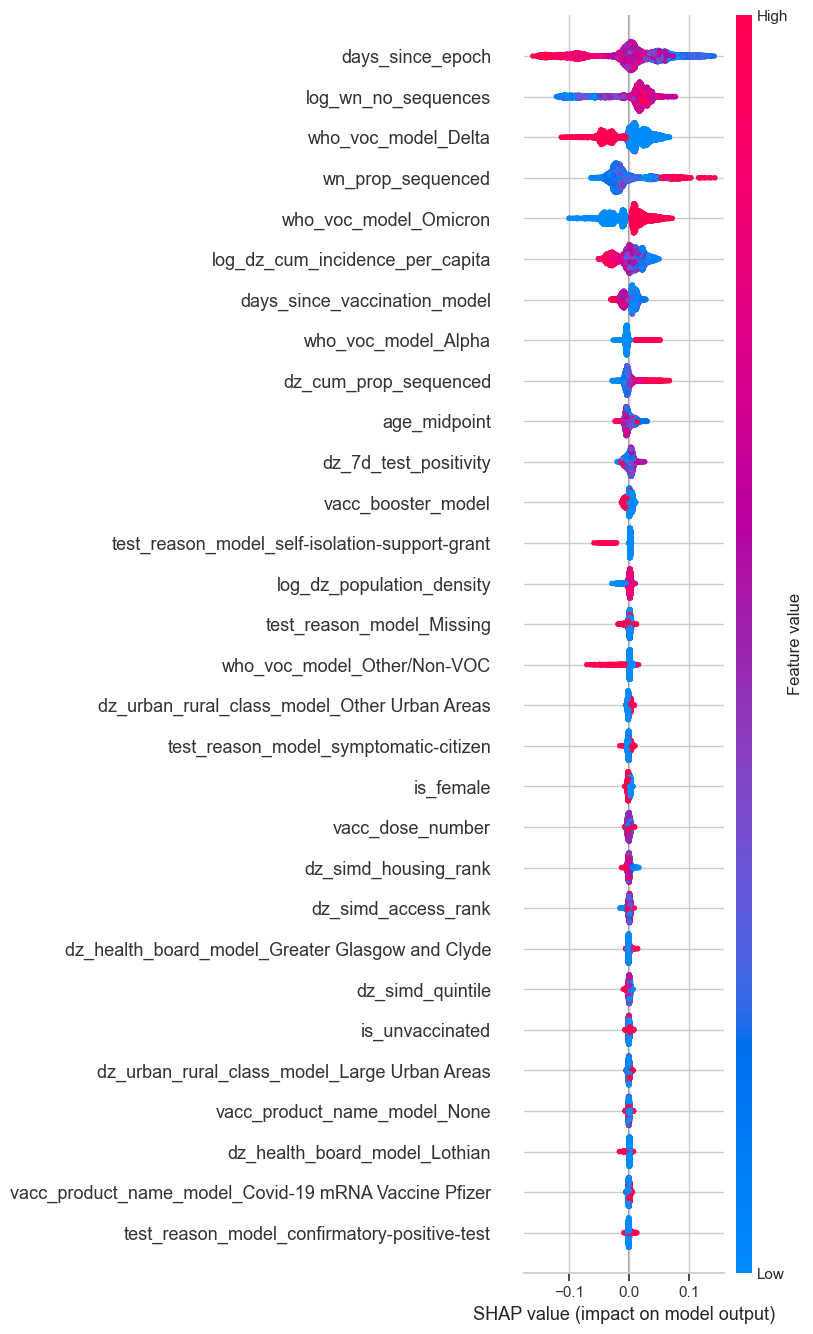

In [23]:
# Optional SHAP analysis. SHAP is not in requirements.txt, so this is off by default.
RUN_SHAP = True
MAX_SHAP_ROWS = 5_000

if RUN_SHAP:
    try:
        import shap
    except ImportError as exc:
        raise ImportError('Install shap first, or keep RUN_SHAP = False.') from exc

    rng = np.random.default_rng(RANDOM_STATE)
    shap_idx = rng.choice(len(X_test), size=min(MAX_SHAP_ROWS, len(X_test)), replace=False)
    X_shap_raw = X_test.iloc[shap_idx].copy()
    X_shap_transformed = binary_model.named_steps['preprocessor'].transform(X_shap_raw)
    if hasattr(X_shap_transformed, 'toarray'):
        X_shap = X_shap_transformed.toarray()
    else:
        X_shap = np.asarray(X_shap_transformed)
    X_shap = np.asarray(X_shap, dtype=np.float64)
    feature_names = binary_model.named_steps['preprocessor'].get_feature_names_out()

    explainer = shap.TreeExplainer(binary_model.named_steps['rf'])
    shap_values = explainer.shap_values(X_shap, check_additivity=False)
    # SHAP versions differ: binary classifiers may return a list or a 3D array.
    if isinstance(shap_values, list):
        large_shap = shap_values[1]
    elif getattr(shap_values, 'ndim', None) == 3:
        large_shap = shap_values[:, :, 1]
    else:
        large_shap = shap_values

    shap.summary_plot(
        large_shap,
        X_shap,
        feature_names=feature_names,
        max_display=30,
        show=True,
    )

### Save SHAP Artefacts

Run this immediately after the SHAP cell if `large_shap`, `X_shap`, `X_shap_raw`, and `feature_names` are still in memory. The compressed `.npz` file preserves the expensive SHAP values so you do not need to recompute them.


In [24]:
# Save expensive SHAP output from the current kernel.
# Requires that the SHAP cell has already run successfully.
required_shap_vars = ['large_shap', 'X_shap', 'X_shap_raw', 'feature_names']
missing_shap_vars = [name for name in required_shap_vars if name not in globals()]
if missing_shap_vars:
    raise RuntimeError(f'Run the SHAP cell first; missing: {missing_shap_vars}')

SHAP_OUT_DIR = OUT_DIR / 'shap'
SHAP_OUT_DIR.mkdir(parents=True, exist_ok=True)

large_shap_array = np.asarray(large_shap, dtype=np.float32)
X_shap_array = np.asarray(X_shap, dtype=np.float32)
feature_names_array = np.asarray(feature_names, dtype=str)

# Full encoded-design SHAP result. This is the file that saves you from recomputing.
np.savez_compressed(
    SHAP_OUT_DIR / 'binary_large_cluster_shap_values_encoded.npz',
    large_shap=large_shap_array,
    X_shap=X_shap_array,
    feature_names=feature_names_array,
    sample_index=X_shap_raw.index.to_numpy(),
)

# Raw sampled rows before preprocessing, useful for joining predictions/covariates later.
X_shap_raw.to_parquet(SHAP_OUT_DIR / 'binary_large_cluster_shap_sample_rows.parquet', index=True)

# Encoded-feature summaries.
shap_feature_summary = (
    pd.DataFrame({
        'encoded_feature': feature_names_array,
        'mean_abs_shap': np.abs(large_shap_array).mean(axis=0),
        'mean_shap': large_shap_array.mean(axis=0),
        'std_shap': large_shap_array.std(axis=0),
    })
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
shap_feature_summary.to_csv(
    SHAP_OUT_DIR / 'binary_large_cluster_shap_encoded_feature_summary.csv',
    index=False,
)

# Collapse one-hot encoded columns back to the original model feature name.
def original_feature_name(encoded_name: str) -> str:
    for feature in ALL_FEATURES:
        if encoded_name == feature or encoded_name.startswith(feature + '_'):
            return feature
    if encoded_name.startswith('missingindicator_'):
        return encoded_name.replace('missingindicator_', '')
    return encoded_name

shap_feature_summary['feature'] = shap_feature_summary['encoded_feature'].map(original_feature_name)
shap_group_summary = (
    shap_feature_summary
    .groupby('feature', as_index=False)
    .agg(
        mean_abs_shap=('mean_abs_shap', 'sum'),
        mean_shap=('mean_shap', 'sum'),
        n_encoded_features=('encoded_feature', 'size'),
    )
    .sort_values('mean_abs_shap', ascending=False)
    .reset_index(drop=True)
)
shap_group_summary.to_csv(
    SHAP_OUT_DIR / 'binary_large_cluster_shap_grouped_feature_summary.csv',
    index=False,
)

print(f'Saved SHAP artefacts to {SHAP_OUT_DIR}')
display(shap_group_summary.head(25))


Saved SHAP artefacts to /Users/ydnkka/Desktop/PhD Project/projects/scotland/cluster_size_rf/outputs/shap


,feature,mean_abs_shap,mean_shap,n_encoded_features
0,who_voc_model,0.059407,-0.002062,7
1,days_since_epoch,0.043762,0.001015,1
2,log_wn_no_sequences,0.032334,0.001381,1
3,wn_prop_sequenced,0.025417,-0.007544,1
4,log_dz_cum_incidence_per_capita,0.016873,0.001503,1
5,test_reason_model,0.010194,0.000382,35
6,days_since_vaccination_model,0.008894,0.001308,1
7,dz_health_board_model,0.006806,-0.000259,14
8,dz_cum_prop_sequenced,0.006235,0.000179,2
9,age_midpoint,0.005346,0.000219,1


## 14. Tertiary Three-class Random Forest

The tertiary three-class model checks whether predictors distinguish `singleton`, `small_cluster`, and `large_cluster`, rather than merely large versus not-large. This is useful as a sensitivity analysis, but the binary large-cluster model is easier to interpret for the superspreading-like question.

In [18]:
if CONFIG['fit_secondary_multiclass']:
    multiclass_model = make_rf_pipeline()
    y_multi_train = y_multiclass.loc[X_train.index].copy()
    y_multi_test = y_multiclass.loc[X_test.index].copy()

    multiclass_model.fit(X_train, y_multi_train)
    multi_pred = multiclass_model.predict(X_test)
    multi_proba = multiclass_model.predict_proba(X_test)
    classes = list(multiclass_model.named_steps['rf'].classes_)

    multi_metrics = {
        'n_rows': len(y_multi_test),
        'balanced_accuracy': balanced_accuracy_score(y_multi_test, multi_pred),
        'macro_f1': f1_score(y_multi_test, multi_pred, average='macro'),
        'weighted_f1': f1_score(y_multi_test, multi_pred, average='weighted'),
        'macro_ovr_auc': roc_auc_score(y_multi_test, multi_proba, multi_class='ovr', average='macro'),
    }
    multi_cm = pd.DataFrame(
        confusion_matrix(y_multi_test, multi_pred, labels=classes),
        index=[f'true_{c}' for c in classes],
        columns=[f'pred_{c}' for c in classes],
    )
    multi_report = pd.DataFrame(classification_report(y_multi_test, multi_pred, output_dict=True, digits=3)).T

    display(pd.DataFrame([multi_metrics]).round(3))
    display(multi_cm)
    display(multi_report.round(3))
else:
    multiclass_model = None
    multi_metrics = None
    multi_cm = None
    multi_report = None
    print('Secondary multiclass model skipped by config.')

,n_rows,balanced_accuracy,macro_f1,weighted_f1,macro_ovr_auc
0,60648,0.474,0.471,0.554,0.674


,pred_large_cluster,pred_singleton,pred_small_cluster
true_large_cluster,21588,2001,8616
true_singleton,2270,2097,2757
true_small_cluster,7516,4045,9758


,precision,recall,f1-score,support
large_cluster,0.688,0.670,0.679,32205.000
singleton,0.258,0.294,0.275,7124.000
small_cluster,0.462,0.458,0.460,21319.000
accuracy,0.551,0.551,0.551,0.551
macro avg,0.469,0.474,0.471,60648.000
weighted avg,0.558,0.551,0.554,60648.000


## 15. Sensitivity: Large-cluster Threshold

Refit the binary model using alternative large-cluster thresholds. Keep the same feature set and grouped split logic. This checks whether results depend on the `>=13` rule.

In [19]:
RUN_THRESHOLD_SENSITIVITY = True

threshold_results = []
if RUN_THRESHOLD_SENSITIVITY:
    for large_min in SENSITIVITY_LARGE_MINS:
        sens_seq = build_sequence_table(raw, PRIMARY_RESOLUTION, large_min)
        sens_df = engineer_features(sens_seq)
        sens_X = sens_df[ALL_FEATURES].copy()
        sens_y = sens_df['is_large_cluster'].copy()
        sens_groups = sens_df['cluster_id'].copy()

        tr, te, sens_split_name = grouped_holdout_split(sens_X, sens_y, sens_groups)
        sens_X_train = sens_X.iloc[tr].copy()
        sens_X_test = sens_X.iloc[te].copy()
        sens_y_train = sens_y.iloc[tr].copy()
        sens_y_test = sens_y.iloc[te].copy()

        model = make_rf_pipeline()
        model.fit(sens_X_train, sens_y_train)
        metrics, _, _, _, _ = evaluate_binary_model(model, sens_X_test, sens_y_test, label=f'large_min_{large_min}')
        metrics['large_min'] = large_min
        metrics['splitter'] = sens_split_name
        threshold_results.append(metrics)

threshold_results = pd.DataFrame(threshold_results)
threshold_results

,label,n_rows,balanced_accuracy,macro_f1,roc_auc,average_precision,large_min,splitter
0,large_min_10,60648,0.645571,0.642578,0.696595,0.724122,10,StratifiedGroupKFold(n_splits=5)
1,large_min_20,60648,0.654758,0.652278,0.712280,0.635661,20,StratifiedGroupKFold(n_splits=5)


## 16. Sensitivity: Primary Resolution

Optional refits at nearby Leiden resolutions. This is slower because each resolution rebuilds the modelling table.

In [20]:
RUN_RESOLUTION_SENSITIVITY = True
SENSITIVITY_RESOLUTIONS = [0.1, 0.2, 0.4, 0.5]

resolution_results = []
if RUN_RESOLUTION_SENSITIVITY:
    for resolution in SENSITIVITY_RESOLUTIONS:
        sens_seq = build_sequence_table(raw, resolution, PRIMARY_LARGE_MIN)
        sens_df = engineer_features(sens_seq)
        sens_X = sens_df[ALL_FEATURES].copy()
        sens_y = sens_df['is_large_cluster'].copy()
        sens_groups = sens_df['cluster_id'].copy()

        tr, te, sens_split_name = grouped_holdout_split(sens_X, sens_y, sens_groups)
        model = make_rf_pipeline()
        model.fit(sens_X.iloc[tr], sens_y.iloc[tr])
        metrics, _, _, _, _ = evaluate_binary_model(model, sens_X.iloc[te], sens_y.iloc[te], label=f'resolution_{resolution}')
        metrics['resolution'] = resolution
        metrics['splitter'] = sens_split_name
        resolution_results.append(metrics)

resolution_results = pd.DataFrame(resolution_results)
resolution_results

,label,n_rows,balanced_accuracy,macro_f1,roc_auc,average_precision,resolution,splitter
0,resolution_0.1,60648,0.654645,0.639258,0.698486,0.821240,0.1,StratifiedGroupKFold(n_splits=5)
1,resolution_0.2,60648,0.622960,0.615216,0.659739,0.733968,0.2,StratifiedGroupKFold(n_splits=5)
2,resolution_0.4,60648,0.651880,0.649450,0.712354,0.666929,0.4,StratifiedGroupKFold(n_splits=5)
3,resolution_0.5,60648,0.665381,0.654139,0.719387,0.611475,0.5,StratifiedGroupKFold(n_splits=5)


## 17. Save Artefacts

This writes the model, feature list, outcome counts, metrics, and permutation importance into `cluster_size_rf/outputs`.

In [21]:
binary_metrics_df = pd.DataFrame([binary_metrics])
binary_metrics_df.to_csv(OUT_DIR / 'binary_large_cluster_metrics.csv', index=False)
binary_cm.to_csv(OUT_DIR / 'binary_large_cluster_confusion_matrix.csv')
binary_report.to_csv(OUT_DIR / 'binary_large_cluster_classification_report.csv')
binary_importance.to_csv(OUT_DIR / 'binary_large_cluster_permutation_importance.csv', index=False)

singleton_metrics_df = pd.DataFrame([singleton_metrics])
singleton_metrics_df.to_csv(OUT_DIR / 'binary_singleton_clustered_metrics.csv', index=False)
singleton_cm.to_csv(OUT_DIR / 'binary_singleton_clustered_confusion_matrix.csv')
singleton_report.to_csv(OUT_DIR / 'binary_singleton_clustered_classification_report.csv')
singleton_importance.to_csv(OUT_DIR / 'binary_singleton_clustered_permutation_importance.csv', index=False)
joblib.dump(singleton_model, OUT_DIR / 'binary_singleton_clustered_random_forest.joblib')
outcome_counts.to_csv(OUT_DIR / 'primary_outcome_counts.csv', index=False)
voc_counts.to_csv(OUT_DIR / 'primary_outcome_by_who_voc.csv')
quarter_counts.to_csv(OUT_DIR / 'primary_outcome_by_quarter.csv')

if 'simd_domain_model' in globals() and simd_domain_model is not None:
    pd.DataFrame([simd_domain_metrics]).to_csv(OUT_DIR / 'simd_domain_large_cluster_metrics.csv', index=False)
    simd_domain_cm.to_csv(OUT_DIR / 'simd_domain_large_cluster_confusion_matrix.csv')
    simd_domain_report.to_csv(OUT_DIR / 'simd_domain_large_cluster_classification_report.csv')
    simd_domain_importance.to_csv(OUT_DIR / 'simd_domain_large_cluster_permutation_importance.csv', index=False)
    joblib.dump(simd_domain_model, OUT_DIR / 'simd_domain_large_cluster_random_forest.joblib')

if CONFIG['fit_secondary_multiclass'] and multiclass_model is not None:
    pd.DataFrame([multi_metrics]).to_csv(OUT_DIR / 'multiclass_cluster_type_metrics.csv', index=False)
    multi_cm.to_csv(OUT_DIR / 'multiclass_cluster_type_confusion_matrix.csv')
    multi_report.to_csv(OUT_DIR / 'multiclass_cluster_type_classification_report.csv')
    joblib.dump(multiclass_model, OUT_DIR / 'multiclass_cluster_type_random_forest.joblib')

if len(threshold_results):
    threshold_results.to_csv(OUT_DIR / 'threshold_sensitivity_metrics.csv', index=False)
if len(resolution_results):
    resolution_results.to_csv(OUT_DIR / 'resolution_sensitivity_metrics.csv', index=False)

joblib.dump(binary_model, OUT_DIR / 'binary_large_cluster_random_forest.joblib')

run_metadata = {
    'run_mode': RUN_MODE,
    'primary_resolution': PRIMARY_RESOLUTION,
    'primary_large_min': PRIMARY_LARGE_MIN,
    'simd_overall_mode': SIMD_OVERALL_MODE,
    'simd_overall_feature': SIMD_OVERALL_FEATURE,
    'simd_domain_features': SIMD_DOMAIN_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'decomposition_numeric_features': DECOMPOSITION_NUMERIC_FEATURES,
    'use_sensitivity_context_controls': USE_SENSITIVITY_CONTEXT_CONTROLS,
    'config': CONFIG,
}
with open(OUT_DIR / 'run_metadata.json', 'w') as f:
    json.dump(run_metadata, f, indent=2)

print(f'Saved artefacts to {OUT_DIR}')

Saved artefacts to /Users/ydnkka/Desktop/PhD Project/projects/scotland/cluster_size_rf/outputs


## 18. Notes for Manuscript Interpretation

Use cautious language:

- The model estimates association with detected large genomic cluster membership.
- Large detected clusters are enriched for superspreading-like amplification, but sequence data alone do not prove a specific superspreading event.
- Surveillance intensity, incidence, variant, calendar time, test reason, and regional context are included because they shape detection and cluster reconstruction.
- Permutation importance ranks predictive contribution; partial dependence/SHAP help with direction. Neither is a causal effect estimate.

Recommended reporting table:

1. Outcome class counts overall and by VOC/wave.
2. Binary large-cluster and binary singleton-versus-clustered metrics on grouped holdout.
3. Top 15 permutation importances for both binary models and the SIMD-domain decomposition model.
4. Direction-of-effect plots for age, SIMD quintile, dose, days since vaccination, reinfection, local sequencing fraction, and incidence.
5. Sensitivity checks for `large_min in {10, 13, 20}` and nearby resolutions.